Loaded 2.0s of audio at 250 kHz
Running LMS adaptive filter...
Done.

Noise band (0-15 kHz) energy reduced by: 94.0%
Click band (100-125 kHz) energy retained: 102.1%
(Want: high noise reduction, ~100% click retention)

Saved: cleaned_signal.wav


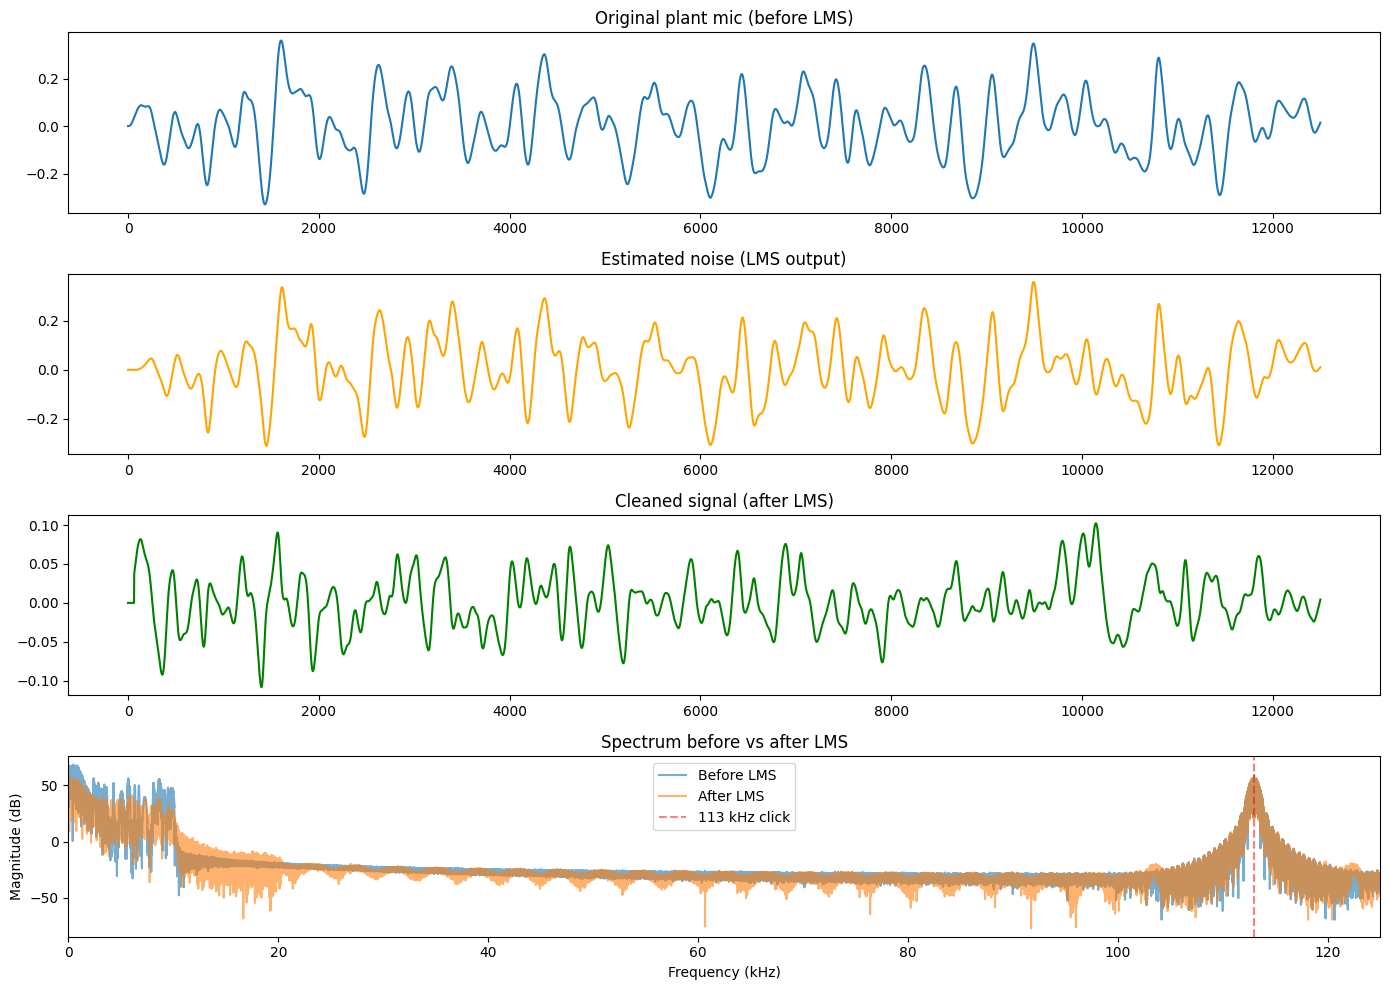

In [1]:
# =============================================================================
# 02_lms_filter.ipynb
# LMS adaptive noise cancellation using the reference (wind-facing) channel
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq

# --- Load Notebook 1's output ---
fs, primary = wavfile.read('plant_mic.wav')
_, reference = wavfile.read('ref_mic.wav')
primary = primary.astype(np.float32) / 32767.0
reference = reference.astype(np.float32) / 32767.0
print(f"Loaded {len(primary)/fs:.1f}s of audio at {fs/1000:.0f} kHz")

def lms_filter(primary, reference, mu=0.003, filter_order=64):
    """Sample-by-sample LMS adaptive canceller (Widrow's algorithm)."""
    N = len(primary)
    w = np.zeros(filter_order)
    y = np.zeros(N)
    e = np.zeros(N)
    for n in range(filter_order, N):
        x = reference[n - filter_order:n][::-1]
        y[n] = np.dot(w, x)
        e[n] = primary[n] - y[n]
        w = w + 2 * mu * e[n] * x
    return e, y, w

print("Running LMS adaptive filter...")
cleaned, estimated_noise, weights = lms_filter(primary, reference, mu=0.003, filter_order=64)
print("Done.")

# --- Quantify: did it actually work? ---
def band_energy(sig, fs, lo, hi):
    spec = np.abs(fft(sig))
    freqs = fftfreq(len(sig), 1/fs)
    mask = (freqs >= lo) & (freqs <= hi)
    return np.sum(spec[mask]**2)

noise_before = band_energy(primary, fs, 0, 15000)
noise_after = band_energy(cleaned, fs, 0, 15000)
click_before = band_energy(primary, fs, 100000, 125000)
click_after = band_energy(cleaned, fs, 100000, 125000)

print(f"\nNoise band (0-15 kHz) energy reduced by: {(1 - noise_after/noise_before)*100:.1f}%")
print(f"Click band (100-125 kHz) energy retained: {(click_after/click_before)*100:.1f}%")
print("(Want: high noise reduction, ~100% click retention)")

# --- Save for Notebook 3 ---
wavfile.write('cleaned_signal.wav', fs, (np.clip(cleaned, -1, 1) * 32767).astype(np.int16))
print("\nSaved: cleaned_signal.wav")

# --- Plot ---
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
show = int(0.05 * fs)

axes[0].plot(primary[:show]); axes[0].set_title("Original plant mic (before LMS)")
axes[1].plot(estimated_noise[:show], color='orange'); axes[1].set_title("Estimated noise (LMS output)")
axes[2].plot(cleaned[:show], color='green'); axes[2].set_title("Cleaned signal (after LMS)")

freq = fftfreq(len(cleaned), 1/fs)[:len(cleaned)//2]
spec_before = np.abs(fft(primary))[:len(primary)//2]
spec_after = np.abs(fft(cleaned))[:len(cleaned)//2]
axes[3].plot(freq/1000, 20*np.log10(spec_before+1e-10), alpha=0.6, label='Before LMS')
axes[3].plot(freq/1000, 20*np.log10(spec_after+1e-10), alpha=0.6, label='After LMS')
axes[3].axvline(x=113, color='red', linestyle='--', alpha=0.5, label='113 kHz click')
axes[3].set_xlim([0, 125]); axes[3].set_xlabel("Frequency (kHz)"); axes[3].set_ylabel("Magnitude (dB)")
axes[3].set_title("Spectrum before vs after LMS"); axes[3].legend()

plt.tight_layout()
plt.show()